# Desafiament 4 — Competencias Financieras (ECF 2021)

Análisis de competencias financieras (conocimiento, actitudes, comportamiento y planificación de la jubilación) a partir de la Encuesta de Competencias Financieras (ECF) 2021, para responder a la pregunta de negocio del reto 4 sobre adaptación de la oferta de Banco Atlas a las tendencias nacionales.

## 0. Tabla de referencia — Variables de Competencias Financieras

Códigos originales de la ECF 2021 (sin traducir). Estado según el pipeline actual del notebook.

### Bloque D — Actitudes (usadas en `score_actitud`)

| Código | Pregunta |
|---|---|
| `d0101` | Antes de comprar algo, considero cuidadosamente si me lo puedo permitir |
| `d0102` | Tiendo a vivir al día, sin pensar en el futuro |
| `d0103` | Prefiero gastar dinero ahora, que ahorrarlo para el futuro |
| `d0104` | Pago las facturas a tiempo |
| `d0105` | Estoy dispuesto a arriesgar un poco de dinero al ahorrar o realizar una inversión, si así puedo obtener un mayor rendimiento en el futuro |
| `d0106` | Vigilo cuidadosamente mis asuntos financieros |
| `d0107` | Me he fijado objetivos financieros a largo plazo y me esfuerzo por alcanzarlos |
| `d0108` | El dinero está para gastarlo |
| `d0109` | Mi situación financiera limita mis posibilidades de hacer cosas que considero importantes |
| `d0110` | Me preocupo por pagar mis gastos habituales |
| `d0111` | Estoy demasiado endeudado ahora mismo |
| `d0112` | Estoy satisfecho con mi situación financiera actual |
| `d0113` | Intento mantenerme informado sobre la evolución de la economía |
| `d0114` | Me preocupa que mi dinero no dure |
| `d0115` | Estoy demasiado ocupado para encargarme de mis finanzas |
| `d0116` | Prefiero comprar cosas con crédito en vez de esperar y ahorrar |
| `d0117` | Pensar en mi situación financiera me genera inquietud |

### Bloque E — Conocimiento financiero (usadas en `score_conocimiento`)

| Código | Pregunta |
|---|---|
| `e0100` | ¿Cómo calificaría sus conocimientos generales sobre temas financieros? (no puntuable, solo autopercepción) |
| `e0500` | Reparto de 1.000€ entre 5 hermanos |
| `e0600` | Reparto tras un año con 1% de inflación |
| `e0700` | Interés de un préstamo entre amigos |
| `e0800` | Interés simple a 1 año |
| `e0900` | Interés compuesto a 5 años |
| `e1001` | Rentabilidad alta = riesgo alto (V/F) |
| `e1002` | Inflación = coste de vida aumenta (V/F) |
| `e1003` | Diversificación reduce riesgo (V/F) |
| `e1101` | Rendimiento de fondos a 6 años (cartón 35) |
| `e1200` | Hipoteca a 15 vs. 30 años (V/F) |
| `e1300` | Confianza en las respuestas del quiz (cargada, no puntuable — no tiene respuesta "correcta") |
| `e1701`/`e1702` | Tipo de interés conveniente para préstamo/ahorro |

### Bloque C — Planificación de la jubilación (usadas en `confianza_jubilacion`)

| Código | Pregunta |
|---|---|
| `c0100` | Confianza en la planificación (si no jubilado) |
| `c0300` | Edad esperada de jubilación (cargada, no explotada aún) |
| `c0500` | Confianza en la planificación (si ya jubilado) |

### Variables comunes de segmentación (Grupo A)

| Código | Pregunta |
|---|---|
| `a04` | Edad |
| `a0000` | Género |
| `a0100` | País de nacimiento (cargada, no explotada) |
| `a1030` | Estado civil (cargada, no explotada) |
| `a1100` | Educación — usada en cruces |
| `a1500`/`a1510` | Situación laboral — usada en cruces |
| `a1800` | Ocupación CNO-2011 (cargada, no explotada) |
| `ccaaf` | Comunidad Autónoma (cargada, no explotada) |

### Pendiente / cargado pero sin usar en el análisis final

| Código | Motivo |
|---|---|
| `c0200a`-`c0200k`, `c0600a`-`c0600k` | Fuentes de ingreso en jubilación — la reducción de multirrespuesta la gestiona Roger en el Master Dataset |
| `b1230a`-`b1230h` | "A quién acudiría" — mismo motivo |
| `f1100` | Quién tiene más conocimiento en el hogar — cargada, sin cruce realizado |

### Descartadas del análisis (documentadas en su momento, nunca incorporadas al pipeline)

| Código | Motivo |
|---|---|
| `a1420a`-`a1420g` | Formación financiera recibida — nunca se añadió a `COMMON_VARS`/`FINANCIAL_COMPETENCIES` |
| `d0300`-`d0500`, `d0610a`-`d0610e` | Preferencia temporal / reparto de ingreso extra — nunca se cargaron |
| `e1400`, `e1500`, `e1600`, `e1800`, `e0300`, `e0401`, `e0402` | Numeracia/razonamiento general — excluidas deliberadamente por no ser competencia financiera específica |

## 1. Tipificación de variables

Tratamiento aplicado a cada tipo de variable dentro del bloque de Competencias:

| Tipo | Variables | Tratamiento aplicado |
|---|---|---|
| Escala Likert 1-5 (frecuencia: 1=Nunca, 5=Siempre) | `d0101`-`d0117` | Convertidas a numérico con `likert_score()`; ítems negativos invertidos (`6 - valor`); combinadas en `score_actitud` (media) |
| Escala 1-5 de confianza, filtrada por situación laboral | `c0100`, `c0500` | Convertidas con `likert_score()` y combinadas en `confianza_jubilacion` (`c0100` si no jubilado, `c0500` si jubilado) |
| Numéricas abiertas | `e0500`, `e0700`, `e0800`, `e0900` | Puntuadas correcto/incorrecto contra el valor exacto esperado |
| Verdadero/Falso | `e1001`, `e1002`, `e1003`, `e1200` | Comparación directa contra `"Verdadero"` |
| Categórica con respuesta correcta única | `e1101` (Fondo 1), `e1701`/`e1702` (tipo de interés) | Comparación directa contra el valor esperado, mismo tratamiento que V/F |
| Suma de aciertos | `e0500`-`e1702` (los 12 anteriores) | `score_conocimiento` (0-12), vía `puntuar_quiz_conocimiento()` |
| Escala 1-10, cargada pero sin uso | `e1300` | Cargada en `df_comp`; no se puntúa (no tiene respuesta correcta) ni se ha cruzado con nada todavía |

**Pendiente / gap conocido:** ni `c0100` ni `c0500` tienen implementado el flag binario para la categoría especial "no tengo plan de jubilación" que se había previsto en su momento — de momento se tratan como escala continua sin ese matiz. No bloquea las conclusiones actuales, pero conviene mencionarlo si alguien pregunta por qué no aparece esa distinción.

**Ya resuelto (nota antigua eliminada):** el notebook no depende del `MasterDataset.csv` de Roger para la construcción de `df_comp` — se trabaja directamente sobre `2026-07-20_ECF_2021_01_raw.dta`, por lo que el nombrado de columnas del master de Roger es irrelevante para este pipeline (solo se usa puntualmente en el ANEXO de comparación de scores).

# 2. Preparació de dades

## 2.0.1 Imports biblioteques

In [73]:
import pandas as pd
from pathlib import Path

## 2.0.2 Importació dades

In [ ]:
data_dir = Path("../Data")
raw_file = data_dir / "2026-07-20_ECF_2021_01_raw.dta"

df = pd.read_stata(raw_file, convert_categoricals=True)
print(df.shape)

(7764, 429)


In [76]:
COMMON_VARS = [
    "a04",      # Edad
    "a0000",    # Sexo
    "a0100",    # País de nacimiento
    "a1030",    # Estado civil
    "a1100",    # Educación
    "a1500",    # Situación laboral
    "a1510",
    "a1800",    # Ocupación CNO-2011
    "ccaaf",    # Comunidad Autónoma
]

FINANCIAL_COMPETENCIES = [
    "e0100",
    "e0500", "e0600", "e0700", "e0800", "e0900",
    "e1001", "e1002", "e1003", "e1101", "e1200",
    "e1300", "e1701", "e1702",
    "c0100", "c0300", "c0500",
]

# ATTITUDES — bloque d0101-d0117, tratado como propio de Competencias
ATTITUDES = [f"d01{n:02d}" for n in range(1, 18)]

cols_needed = COMMON_VARS + FINANCIAL_COMPETENCIES + ATTITUDES

faltantes = [c for c in cols_needed if c not in df.columns]
print("Faltantes:", faltantes)

df_comp = df[[c for c in cols_needed if c in df.columns]].copy()

COLUMNAS_NUMERICAS = ["a04", "e0500", "e0700", "e0800"]
for col in COLUMNAS_NUMERICAS:
    df_comp[col] = pd.to_numeric(df_comp[col], errors="coerce")

print(df_comp.shape)

Faltantes: []
(7764, 43)


In [77]:
COLUMNAS_NUMERICAS = ["a04", "e0500", "e0700", "e0800"]

for col in COLUMNAS_NUMERICAS:
    df_comp[col] = pd.to_numeric(df_comp[col], errors="coerce")

df_comp[COLUMNAS_NUMERICAS].describe()

,a04,e0500,e0700,e0800
count,7755.000000,7450.000000,7673.000000,6303.000000
mean,46.941586,267.938416,0.388523,133.597947
std,15.643214,1990.368653,9.504984,318.956813
min,18.000000,-5.000000,-5.000000,-5.000000
25%,35.000000,200.000000,0.000000,102.000000
50%,47.000000,200.000000,0.000000,102.000000
75%,59.000000,200.000000,0.000000,102.000000
max,80.000000,170000.000000,500.000000,12500.000000


## 2.1 Neteja general codis especials

In [78]:
# ============================================================
# 2.1 NETEJA GENERAL DE CODIS ESPECIALS
# ============================================================
CODIGOS_ESPECIALES = [-97, -98, -99, -5]
TEXTOS_ESPECIALES = ["No sabe", "No contesta", "No ha lugar (no aplica filtro)"]

def limpiar_codigos_especiales(df, columnas, codigos=CODIGOS_ESPECIALES, textos=TEXTOS_ESPECIALES):
    df_limpio = df.copy()
    valores_txt = [str(v) for v in codigos] + list(textos)
    for col in columnas:
        s = df_limpio[col]
        if pd.api.types.is_numeric_dtype(s):
            df_limpio[col] = s.mask(s.isin(codigos))
        else:
            df_limpio[col] = s.mask(s.astype("string").isin(valores_txt))
    return df_limpio

df_comp = limpiar_codigos_especiales(df_comp, df_comp.columns)

## 2.2 Puntuació del quiz coneixement

In [79]:
# ============================================================
# 2.2 PUNTUACIÓN DEL QUIZ DE CONOCIMIENTO
# ============================================================
RESPUESTAS_CORRECTAS = {
    "e0500": 200,
    "e0600": "c. Menos de lo que podrían comprar hoy",
    "e0700": 0,
    "e0800": 102,
    "e0900": "Más de 110 euros",
    "e1001": "Verdadero",
    "e1002": "Verdadero",
    "e1003": "Verdadero",
    "e1101": "Fondo 1 (Azul)",
    "e1200": "Verdadero",
    "e1701": "Tipo de interés del 1%",
    "e1702": "Tipo de interés del 3%",
}

def puntuar_quiz_conocimiento(df, respuestas_correctas=RESPUESTAS_CORRECTAS):
    df_score = df.copy()
    columnas_score = []
    for var, ok in respuestas_correctas.items():
        col = f"{var}_correcta"
        df_score[col] = (df_score[var] == ok).astype("Int64")
        df_score.loc[df_score[var].isna(), col] = pd.NA
        columnas_score.append(col)
    df_score["score_conocimiento"] = df_score[columnas_score].sum(axis=1, min_count=1)
    return df_score

df_comp = puntuar_quiz_conocimiento(df_comp)

print("Distribución score_conocimiento (0-12):")
print(df_comp["score_conocimiento"].value_counts().sort_index())
print(f"\nMedia: {df_comp['score_conocimiento'].mean():.2f}")

Distribución score_conocimiento (0-12):
score_conocimiento
0        1
1       12
2       44
3       80
4      181
5      336
6      597
7      838
8     1074
9     1346
10    1377
11    1173
12     703
Name: count, dtype: Int64

Media: 8.76


## 2.3 Score Actituds

In [80]:
# ============================================================
# 2.3 SCORE DE ACTITUDES (media Likert, ítems negativos invertidos)
# ============================================================
def likert_score(s):
    return pd.to_numeric(s.astype("string").str.extract(r"^\s*(\d+)", expand=False), errors="coerce")

ITEMS_POSITIVOS = ["d0101", "d0104", "d0105", "d0106", "d0107", "d0113"]
ITEMS_NEGATIVOS = ["d0102", "d0103", "d0108", "d0109", "d0110", "d0114", "d0115", "d0116", "d0117"]

for col in ITEMS_POSITIVOS + ITEMS_NEGATIVOS:
    df_comp[f"{col}_num"] = likert_score(df_comp[col])

vals = pd.DataFrame(index=df_comp.index)
for c in ITEMS_POSITIVOS:
    vals[c] = df_comp[f"{c}_num"]
for c in ITEMS_NEGATIVOS:
    vals[c] = 6 - df_comp[f"{c}_num"]

df_comp["score_actitud"] = vals.mean(axis=1, skipna=True)



## 2.4 Tramos de edad

In [81]:
# ============================================================
# 2.4 TRAMOS DE EDAD (alineados con los grupos de edad del INE)
# ============================================================

bins=[17,24,34,44,54,64,120]
labels=[
        "18-24 Jóvenes",
        "25-34 Jóvenes adultos",
        "35-44 Adultos iniciales",
        "45-54 Adultos maduros",
        "55-64 Mediana edad",
        "65+ Sénior"
    ]


df_comp["tramo_edad"] = pd.cut(
    df_comp["a04"],
    bins=bins,
    labels=labels,
    right=True
)


## 2.5 Primer encreuaments

In [82]:
# ============================================================
# 5. PRIMEROS CRUCES
# ============================================================
print("\n--- Score conocimiento por tramo de edad ---")
print(df_comp.groupby("tramo_edad", observed=True)["score_conocimiento"].agg(["mean", "count"]))

print("\n--- Score conocimiento por nivel educativo ---")
print(df_comp.groupby("a1100", observed=True)["score_conocimiento"].agg(["mean", "count"]).sort_values("mean"))

print("\n--- Score conocimiento por situación laboral ---")
print(df_comp.groupby("a1500", observed=True)["score_conocimiento"].agg(["mean", "count"]).sort_values("mean"))

print("\n--- Score actitud por tramo de edad ---")
print(df_comp.groupby("tramo_edad", observed=True)["score_actitud"].agg(["mean", "count"]))


--- Score conocimiento por tramo de edad ---
                             mean  count
tramo_edad                              
18-24 Jóvenes            8.107188    793
25-34 Jóvenes adultos    8.809222   1106
35-44 Adultos iniciales  9.035374   1470
45-54 Adultos maduros    9.099389   1801
55-64 Mediana edad       8.965181   1436
65+ Sénior               8.055798   1147

--- Score conocimiento por nivel educativo ---
                                                         mean  count
a1100                                                               
a. Menos de primaria Incluye analfabetos, perso...   5.147059     68
b. Educación primaria Incluye sabe leer y escri...   6.991184    794
c. Primera etapa de Educación Secundaria y similar   7.945253   1717
d. Segunda etapa de Educación Secundaria y similar   8.750273   1834
e. Educación postsecundaria no superior              9.020619     97
f. Enseñanzas de Formación Profesional de Grado...   9.197483   1033
g. Diplomaturas universita

### 2.5.1 Conclusiones (primera lectura numérica, antes de visualizar)

**Educación: gradiente perfecto, y es una buena señal metodológica**

De "menos de primaria" (5,15) a "doctorado" (10,48), la progresión es monotónica y neta — cada nivel educativo sube respecto al anterior sin excepciones. Más allá del interés de negocio, esto es una validación implícita de que el score se comporta como debería: si un indicador de competencia financiera no correlacionase con la educación, sería motivo de sospecha metodológica.

**Situación laboral: alerta con una categoría**

Los activos (autónomos 9,30, por cuenta ajena 9,11) y estudiantes (8,53) puntúan alto; "se ocupa del hogar" (7,24) e incapacidad permanente (7,67) puntúan bajo. Pero "Otros (especificar)" tiene n=5 — no usar esta categoría para ninguna conclusión ni mostrarla en la presentación con ese peso, la media de 5,6 no es fiable con tan poca muestra.

**Actitud: plana, casi sin variación por edad**

Aquí el contraste con el conocimiento es el propio insight: mientras el conocimiento varía mucho por edad (8,06 a 9,10), la actitud se mantiene prácticamente plana (3,37-3,46 sobre 5) en todos los tramos. Sugiere que las diferencias de competencia financiera por edad vienen sobre todo del conocimiento aprendido, no de una actitud fundamentalmente distinta hacia el dinero.

In [83]:
df_comp.groupby("tramo_edad", observed=True).size()

tramo_edad
18-24 Jóvenes               793
25-34 Jóvenes adultos      1106
35-44 Adultos iniciales    1470
45-54 Adultos maduros      1801
55-64 Mediana edad         1436
65+ Sénior                 1149
dtype: int64

# 3. Visualizaciones de datos
## 3.1 CONOCIMIENTO FINANCIERO POR RANGO DE EDAD

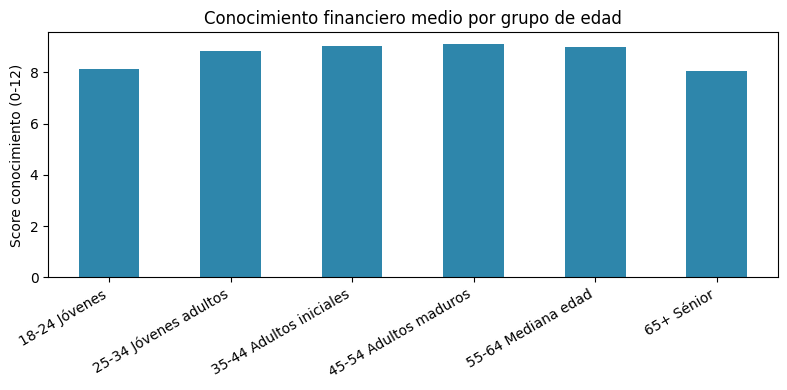

In [84]:
import matplotlib.pyplot as plt

resumen_edad = df_comp.groupby("tramo_edad", observed=True)["score_conocimiento"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
resumen_edad.plot(kind="bar", ax=ax, color="#2E86AB")
ax.set_ylabel("Score conocimiento (0-12)")
ax.set_xlabel("")
ax.set_title("Conocimiento financiero medio por grupo de edad")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
# plt.savefig("../Results/score_conocimiento_por_edad.png", dpi=150)
plt.show()

### 3.1.1 Conclusiones
1. El coneixement financer segueix una U invertida per edat; l'actitud es manté plana. El segment 65+ (el que l'INE projecta com el que més creix) té el segon score més baix de tots (8,06/12), només per sobre dels joves de 18-24.

2. L'educació és el predictor més net i monotònic (5,15 sense estudis → 10,48 doctorat) — el gradient més fort de tots els que hem mirat.

3. Els actius (autònoms/per compte d'altri) puntuen més alt que jubilats, aturats o "se ocupa del hogar" — situació laboral i edat es mouen junts però no diuen exactament el mateix.

## 3.2 CONOCIMIENTO FINANCIERO × TENENCIA DE PRODUCTOS BANCARIOS

In [85]:
# ============================================================
# 3.2 CONOCIMIENTO FINANCIERO × TENENCIA DE PRODUCTOS BANCARIOS
# (equivalentes ECF de housing/loan/deposit de Banco Atlas)
# ============================================================

productos_map = {
    "b0301": "tiene_hipoteca",       # equivalente a housing
    "b0306": "tiene_prestamo",       # equivalente a loan
    "b0308": "tiene_deposito_ahorro" # equivalente a deposit
}

df_productos = df[list(productos_map.keys())].copy()

df_productos = df_productos.rename(columns=productos_map)

for col in productos_map.values():
    df_productos[col] = (df_productos[col].astype("string").str.strip() == "Sí")

df_cruce = df_comp[["score_conocimiento", "score_actitud", "tramo_edad", "a1100"]].join(df_productos)

# --- Cruce 1: score medio según tenencia de cada producto ---
for col in productos_map.values():
    print(f"\n--- Score conocimiento según {col} ---")
    print(df_cruce.groupby(col, observed=True)["score_conocimiento"].agg(["mean", "count"]))

# --- Cruce 2: combinación Hipoteca + Depósito (el perfil dominante del reto 1-2) ---
df_cruce["hipoteca_y_deposito"] = (
    df_cruce["tiene_hipoteca"] & df_cruce["tiene_deposito_ahorro"]
)

print("\n--- Score conocimiento: perfil Hipoteca+Depósito vs resto ---")
print(df_cruce.groupby("hipoteca_y_deposito", observed=True)["score_conocimiento"].agg(["mean", "count"]))

# --- Cruce 3: número de productos financieros que tiene vs score ---
df_cruce["n_productos_basicos"] = (
    df_cruce["tiene_hipoteca"].astype(int)
    + df_cruce["tiene_prestamo"].astype(int)
    + df_cruce["tiene_deposito_ahorro"].astype(int)
)

print("\n--- Score conocimiento según número de productos ---")
print(df_cruce.groupby("n_productos_basicos", observed=True)["score_conocimiento"].agg(["mean", "count"]))


--- Score conocimiento según tiene_hipoteca ---
                    mean  count
tiene_hipoteca                 
False           8.515752   5396
True            9.322063   2366

--- Score conocimiento según tiene_prestamo ---
                    mean  count
tiene_prestamo                 
False           8.702321   6161
True            8.989382   1601

--- Score conocimiento según tiene_deposito_ahorro ---
                           mean  count
tiene_deposito_ahorro                 
False                   8.58453   6335
True                   9.547302   1427

--- Score conocimiento: perfil Hipoteca+Depósito vs resto ---
                         mean  count
hipoteca_y_deposito                 
False                8.681364   7212
True                 9.812727    550

--- Score conocimiento según número de productos ---
                         mean  count
n_productos_basicos                 
0                    8.298311   3731
1                    9.041431   2824
2                    

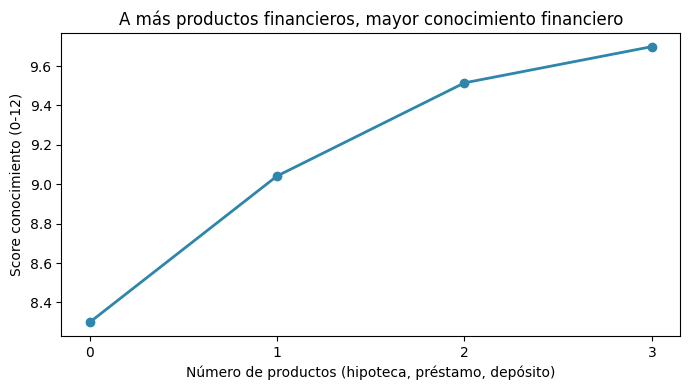

In [86]:
resumen_productos = df_cruce.groupby("n_productos_basicos", observed=True)["score_conocimiento"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
resumen_productos.plot(kind="line", marker="o", ax=ax, color="#2E86AB", linewidth=2)
ax.set_ylabel("Score conocimiento (0-12)")
ax.set_xlabel("Número de productos (hipoteca, préstamo, depósito)")
ax.set_title("A más productos financieros, mayor conocimiento financiero")
ax.set_xticks([0, 1, 2, 3])
plt.tight_layout()
# plt.savefig("../Results/score_conocimiento_por_n_productos.png", dpi=150)
plt.show()

### 3.2.1 Conclusiones 
- Existe un gradiente monotónico y sin excepciones entre número de productos financieros y conocimiento: 8,30 (0 productos) → 9,04 (1) → 9,51 (2) → 9,70 (3).
- El perfil "Hipoteca + Depósito" —identificado como dominante en los retos 1 y 2— es también el más competente financieramente: 9,81 frente a 8,68 del resto (la mayor brecha de todo el estudio).
- Por producto individual, el depósito de ahorro (8,58 → 9,55) y la hipoteca (8,52 → 9,32) muestran la asociación más fuerte con el conocimiento; el préstamo personal apenas la muestra (8,70 → 8,99).
- Advertencia metodológica: es correlación, no causalidad. No se puede afirmar si el conocimiento lleva a adquirir más productos o si la relación con el banco genera aprendizaje.

## 3.3 CONFIANZA JUBILACIÓN

In [87]:
score_c0100 = likert_score(df_comp["c0100"])
score_c0500 = likert_score(df_comp["c0500"])

df_comp["confianza_jubilacion"] = score_c0100.where(score_c0100.notna(), score_c0500)

print("--- Confianza en planificación de jubilación por grupo de edad ---")
print(df_comp.groupby("tramo_edad", observed=True)["confianza_jubilacion"].agg(["mean", "count"]))

print("\n--- Correlación confianza jubilación vs score_conocimiento ---")
print(df_comp[["confianza_jubilacion", "score_conocimiento"]].corr())

--- Confianza en planificación de jubilación por grupo de edad ---
                             mean  count
tramo_edad                              
18-24 Jóvenes            2.830075    665
25-34 Jóvenes adultos    2.767283   1027
35-44 Adultos iniciales  2.929437   1403
45-54 Adultos maduros    3.026605   1729
55-64 Mediana edad       3.250549   1365
65+ Sénior                3.47886   1088

--- Correlación confianza jubilación vs score_conocimiento ---
                      confianza_jubilacion  score_conocimiento
confianza_jubilacion              1.000000            0.111933
score_conocimiento                0.111933            1.000000


                         confianza_jubilacion  score_conocimiento     n
tramo_edad                                                             
18-24 Jóvenes                        2.830075            8.107188   665
25-34 Jóvenes adultos                2.767283            8.809222  1027
35-44 Adultos iniciales              2.929437            9.035374  1403
45-54 Adultos maduros                3.026605            9.099389  1729
55-64 Mediana edad                   3.250549            8.965181  1365
65+ Sénior                            3.47886            8.055798  1088


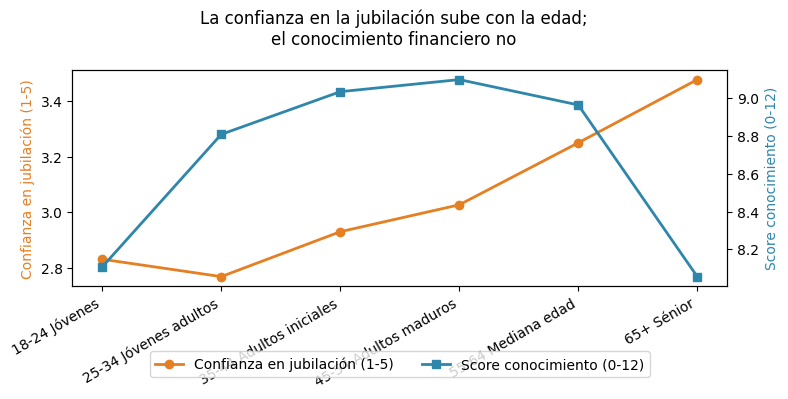

In [88]:
# ============================================================
# 3.3 Confianza en la planificación de la jubilación
# ============================================================
resumen_jubilacion = df_comp.groupby("tramo_edad", observed=True).agg(
    confianza_jubilacion=("confianza_jubilacion", "mean"),
    score_conocimiento=("score_conocimiento", "mean"),
    n=("confianza_jubilacion", "count"),
)
print(resumen_jubilacion)

fig, ax1 = plt.subplots(figsize=(8, 4.5))

x = range(len(resumen_jubilacion))
ax1.plot(x, resumen_jubilacion["confianza_jubilacion"], marker="o", color="#E67E22",
         linewidth=2, label="Confianza en jubilación (1-5)")
ax1.set_ylabel("Confianza en jubilación (1-5)", color="#E67E22")
ax1.set_xticks(list(x))
ax1.set_xticklabels(resumen_jubilacion.index, rotation=30, ha="right")

ax2 = ax1.twinx()
ax2.plot(x, resumen_jubilacion["score_conocimiento"], marker="s", color="#2E86AB",
         linewidth=2, label="Score conocimiento (0-12)")
ax2.set_ylabel("Score conocimiento (0-12)", color="#2E86AB")

fig.suptitle("La confianza en la jubilación sube con la edad;\nel conocimiento financiero no")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower center", bbox_to_anchor=(0.5, -0.45), ncol=2)

plt.tight_layout()
# plt.savefig("../Results/confianza_vs_conocimiento_jubilacion.png", dpi=150)
plt.show()

### 3.3.1 Conclusiones
- La confianza en la planificación de la jubilación aumenta de forma constante con la edad (2,83 en 18-24 años → 3,48 en 65+), justo en dirección contraria al conocimiento financiero, que cae en ese mismo tramo.
- La correlación entre confianza y conocimiento es prácticamente nula (r=0,11): la confianza no está sustentada en un mayor conocimiento objetivo.
- Esto sugiere un riesgo de exceso de confianza (overconfidence) en el segmento 65+, el mismo que las proyecciones del INE identifican como creciente.
- Implicación de negocio: el segmento 65+ necesita productos acompañados de asesoramiento no por desconfianza propia, sino a pesar de la confianza que ya sienten — un matiz relevante para el mensaje comercial (evitar un tono que asuma desconfianza donde en realidad hay seguridad, quizás mal fundamentada).

## 3.4 CONFIANZA EN LA JUBILACIÓN POR SITUACIÓN LABORAL

                                                 confianza_jubilacion  \
a1500                                                                   
d. Desempleado                                               2.582667   
h. Estudiante, escolar o en formación                        2.696347   
Otros (especificar)                                               2.8   
c. Se ocupa de su hogar                                         2.912   
f. No puede trabajar por incapacidad permanente               2.93662   
b. Trabaja por cuenta ajena                                  3.060639   
a. Trabaja por cuenta propia                                 3.082045   
g. No trabaja ni busca trabajo                               3.297297   
e. Jubilado o jubilación anticipada                          3.625363   

                                                 score_conocimiento     n  
a1500                                                                      
d. Desempleado                              

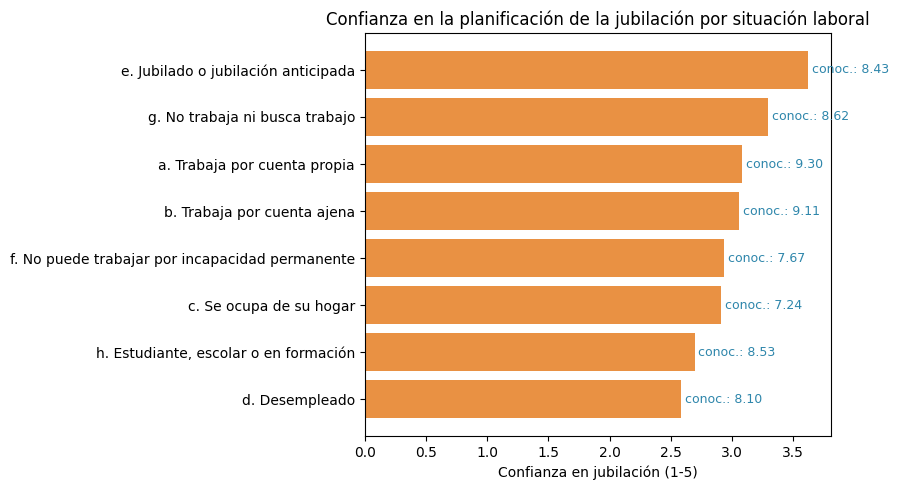

In [90]:
# ============================================================
# 3.4 Confianza en jubilación y conocimiento por situación laboral
# ============================================================
resumen_laboral = df_comp.groupby("a1500", observed=True).agg(
    confianza_jubilacion=("confianza_jubilacion", "mean"),
    score_conocimiento=("score_conocimiento", "mean"),
    n=("confianza_jubilacion", "count"),
).sort_values("confianza_jubilacion")

# Excluimos "Otros (especificar)" del gráfico por tamaño muestral insuficiente (n=5)
resumen_laboral_plot = resumen_laboral.drop(index="Otros (especificar)", errors="ignore")

print(resumen_laboral)

fig, ax = plt.subplots(figsize=(9, 5))
y = range(len(resumen_laboral_plot))

ax.barh(y, resumen_laboral_plot["confianza_jubilacion"], color="#E67E22", alpha=0.85, label="Confianza jubilación (1-5)")
ax.set_yticks(list(y))
ax.set_yticklabels(resumen_laboral_plot.index)
ax.set_xlabel("Confianza en jubilación (1-5)")
ax.set_title("Confianza en la planificación de la jubilación por situación laboral")

# Anotamos el score de conocimiento al lado de cada barra para contraste
for i, (conf, con) in enumerate(zip(resumen_laboral_plot["confianza_jubilacion"], resumen_laboral_plot["score_conocimiento"])):
    ax.text(conf + 0.03, i, f"conoc.: {con:.2f}", va="center", fontsize=9, color="#2E86AB")

plt.tight_layout()
# plt.savefig("../Results/confianza_conocimiento_por_situacion_laboral.png", dpi=150)
plt.show()

### 3.4.1 Conclusiones
- Los desempleados muestran la menor confianza en su planificación de jubilación (2,58), incluso por debajo de los estudiantes (2,70) — refleja cómo la inestabilidad laboral presente contamina la percepción sobre el futuro.
- Los jubilados presentan la mayor confianza (3,63), consistente con el patrón por edad ya visto en 3.3.
- Autónomos (3,08) y asalariados (3,06) muestran una confianza casi idéntica, pese a que los autónomos cuentan típicamente con una cobertura pública de pensión inferior por su régimen de cotización — una posible brecha entre confianza percibida y riesgo real (ver conclusión 5 del apartado 4).
- En conocimiento, el orden es distinto: autónomos (9,30) y asalariados (9,11) sí encabezan, mientras que confianza y conocimiento van en direcciones opuestas en desempleados y jubilados — mismo patrón de desacoplamiento visto por edad.

## 3.5 Migracion

In [91]:
print(df_comp["a0100"].value_counts(dropna=False))

a0100
España       6824
Otro país     940
Name: count, dtype: int64


In [92]:
print("\n--- Score conocimiento según país de nacimiento ---")
print(df_comp.groupby("a0100", observed=True)["score_conocimiento"].agg(["mean", "count"]))

print("\n--- Confianza en jubilación según país de nacimiento ---")
print(df_comp.groupby("a0100", observed=True)["confianza_jubilacion"].agg(["mean", "count"]))

# Test estadístico (solo si ambos grupos tienen n >= 20, si no, no es fiable)
grupos = [g["score_conocimiento"].dropna() for _, g in df_comp.groupby("a0100", observed=True)]
if len(grupos) == 2 and min(len(g) for g in grupos) >= 20:
    u, p = stats.mannwhitneyu(grupos[0], grupos[1], alternative="two-sided")
    r = 2 * u / (len(grupos[0]) * len(grupos[1])) - 1
    print(f"\nMann-Whitney U={u:.0f}, p={p:.2e}, r={r:.3f}")
else:
    print("\nMuestra insuficiente en alguno de los grupos para un test fiable.")


--- Score conocimiento según país de nacimiento ---
              mean  count
a0100                    
Otro país  8.23617    940
España     8.83392   6822

--- Confianza en jubilación según país de nacimiento ---
               mean  count
a0100                     
Otro país   2.85504    883
España     3.091733   6399

Mann-Whitney U=2665531, p=2.26e-17, r=-0.169


**3.5.1 Conclusiones**

- Las personas nacidas fuera de España muestran un conocimiento financiero ligeramente inferior a la media (8,24 frente a 8,83) y también una menor confianza en su planificación de jubilación (2,86 frente a 3,09) — a diferencia del segmento Sénior, aquí ambas variables se mueven en la misma dirección, sin señal de exceso de confianza.
- La diferencia es estadísticamente significativa (Mann-Whitney U, p<0,001) con un tamaño de efecto pequeño-moderado (r=0,169), superior al de la edad considerada de forma aislada pero inferior al de la educación o el perfil de tenencia de productos.
- Limitación relevante: la variable disponible (`a0100`) solo distingue "España" frente a "otro país", sin desglose por tiempo de residencia, región de origen o motivo migratorio — no permite afirmar nada sobre integración ni sobre cómo evoluciona esta brecha con los años de residencia.
- No se dispone de un cruce edad × país de nacimiento, por lo que esta brecha no puede vincularse directamente al crecimiento poblacional proyectado por el INE (impulsado mayoritariamente por saldo migratorio) sin asumir que ambos fenómenos coinciden en las mismas personas.

## 3.6 Tests estadísticos

In [96]:
def epsilon_squared(h, n, k):
    return max(0.0, (h - k + 1) / max(n - k, 1))

def kruskal_por_grupo(df, variable_numerica, variable_grupo):
    grupos = [
        g[variable_numerica].dropna()
        for _, g in df.groupby(variable_grupo, observed=True)
    ]
    grupos = [g for g in grupos if len(g) >= 20]
    h, p = stats.kruskal(*grupos)
    eff = epsilon_squared(h, sum(len(g) for g in grupos), len(grupos))
    print(f"{variable_grupo}: Kruskal-Wallis H={h:.2f}, p={p:.2e}, ε²={eff:.4f}")
    return h, p, eff

def mannwhitney_binaria(df, variable_numerica, variable_binaria):
    grupos = [g[variable_numerica].dropna() for _, g in df.groupby(variable_binaria, observed=True)]
    u, p = stats.mannwhitneyu(grupos[0], grupos[1], alternative="two-sided")
    r = 2 * u / (len(grupos[0]) * len(grupos[1])) - 1
    print(f"{variable_binaria}: Mann-Whitney U={u:.0f}, p={p:.2e}, r={r:.3f}")
    return u, p, r

# Confirmación estadística de los hallazgos ya vistos
kruskal_por_grupo(df_comp, "score_conocimiento", "tramo_edad")
kruskal_por_grupo(df_comp, "score_conocimiento", "a1100")
kruskal_por_grupo(df_comp, "score_conocimiento", "a1500")

# Comparación binaria: perfil Hipoteca+Depósito vs resto
grupo_si = df_cruce.loc[df_cruce["hipoteca_y_deposito"], "score_conocimiento"].dropna()
grupo_no = df_cruce.loc[~df_cruce["hipoteca_y_deposito"], "score_conocimiento"].dropna()
u, p = stats.mannwhitneyu(grupo_si, grupo_no, alternative="two-sided")
rank_biserial = 2 * u / (len(grupo_si) * len(grupo_no)) - 1
print(f"Hipoteca+Depósito: Mann-Whitney U={u:.0f}, p={p:.2e}, r={rank_biserial:.3f}")

# País de nacimiento (migración) — mismo criterio, ahora integrado con el resto de tests
mannwhitney_binaria(df_comp, "score_conocimiento", "a0100")

tramo_edad: Kruskal-Wallis H=234.23, p=1.33e-48, ε²=0.0296
a1100: Kruskal-Wallis H=1552.20, p=0.00e+00, ε²=0.1992
a1500: Kruskal-Wallis H=459.22, p=4.65e-95, ε²=0.0584
Hipoteca+Depósito: Mann-Whitney U=2579862, p=1.29e-32, r=0.301
a0100: Mann-Whitney U=2665531, p=2.26e-17, r=-0.169


(np.float64(2665531.0),
 np.float64(2.263805968295881e-17),
 np.float64(-0.16866863776143515))

### 3.6.1 Conclusiones
Dado que score_conocimiento es una suma de items binarios y no se puede asumir normalidad, se opta por pruebas paramétricas (Kruskal-Wallis, Mann-Whitney U) en lugar de comparacion de medianas asumiendo normalidad. Todas las relaciones exploradas resultan estadisticamente significativas (p>0,001), con medidas de efecto (ε², r) que confirman que educaciónZperfil de producto>situacion laboral>edad en fuerza de asociación.

# 4. Conclusiones finales — Competencias Financieras

### Síntesis de hallazgos

1. **El conocimiento financiero sigue una U invertida por edad, con mínimo relativo en el segmento que más crece según el INE.** El grupo 65+ —que las proyecciones poblacionales sitúan como el de mayor crecimiento relativo hasta 2036— presenta el segundo score de conocimiento más bajo (8,06/12), solo por delante de los jóvenes de 18-24.

2. **La educación es el predictor más fuerte y consistente** (5,15 sin estudios → 10,48 doctorado), con un gradiente monotónico sin excepciones — la evidencia más clara de validez del índice construido.

3. **La tenencia de productos financieros se asocia con mayor competencia de forma gradual**: 8,30 (ningún producto) → 9,70 (los tres). El perfil "Hipoteca + Depósito", ya identificado como dominante en los retos 1 y 2, es también el más competente (9,81 frente a 8,68 del resto) — la mayor brecha de todo el estudio.

4. **La confianza en la planificación de la jubilación crece con la edad mientras el conocimiento no lo hace**, y ambas variables están prácticamente desacopladas (r=0,11). El segmento 65+ combina la mayor confianza con un conocimiento financiero por debajo de la media — un patrón de posible exceso de confianza (overconfidence).

5. **Los autónomos muestran una confianza en su planificación de jubilación prácticamente idéntica a la de los asalariados (3,08 vs 3,06), pese a contar típicamente con una cobertura pública de pensión inferior por su régimen de cotización.** Esto sugiere una posible brecha entre la confianza percibida y el riesgo real de este colectivo, y representa una oportunidad concreta para productos de pensión privada dirigidos específicamente a autónomos.

6. **Las personas nacidas fuera de España muestran una brecha moderada tanto en conocimiento financiero como en confianza sobre su jubilación** (a diferencia del segmento Sénior, sin señal de exceso de confianza en este caso). Dado que el crecimiento poblacional proyectado por el INE procede mayoritariamente del saldo migratorio, esta brecha —aunque no se pueda vincular directamente al mismo grupo de edad sin más información— sugiere que Banco Atlas podría beneficiarse de estrategias de educación financiera específicamente adaptadas a la población de origen extranjero, como parte de su respuesta a las tendencias demográficas nacionales.

### Respuesta a la pregunta de negocio

En relación con la pregunta del reto (¿es necesario adaptar la oferta actual o crear productos nuevos según las tendencias de competencias financieras?), el conjunto de hallazgos apunta a que el ajuste necesario **no es principalmente de producto, sino de acompañamiento, y dirigido a perfiles concretos más que a la población general.**

La validación estadística (Kruskal-Wallis, Mann-Whitney U) confirma que todas las relaciones exploradas son significativas, pero con magnitudes muy distintas: la **educación** es, con diferencia, el factor con mayor peso (ε²=0,199), seguida del **perfil de tenencia de productos** (r=0,301), la **situación laboral** (ε²=0,058), la **edad** (ε²=0,030) y el **país de nacimiento** (r=0,169). Esto es relevante porque la narrativa demográfica de esta semana gira en torno a la edad (por las proyecciones del INE), pero en términos de fuerza de asociación no es la variable más determinante — es la más relevante para *esta* pregunta de negocio concreta, no la de mayor peso explicativo en términos absolutos.

Con esa jerarquía en mente, los hallazgos configuran tres focos de actuación:

1. **El segmento Sénior** (65+), el de mayor crecimiento proyectado por el INE, combina conocimiento financiero por debajo de la media con la mayor confianza en su planificación de jubilación — un patrón de posible exceso de confianza que requiere acompañamiento, no solo producto.
2. **Los autónomos**, pese a contar típicamente con menor cobertura pública de pensión, muestran una confianza en su planificación casi idéntica a la de los asalariados — una brecha entre confianza y riesgo real que representa una oportunidad concreta para planes de pensión privada dirigidos a este colectivo.
3. **La población nacida fuera de España** —componente principal del crecimiento poblacional según el INE— muestra una brecha moderada y consistente (sin exceso de confianza) tanto en conocimiento como en confianza financiera, lo que sugiere valorar programas de educación financiera adaptados a este perfil.

Por el lado positivo, el perfil más rentable de Banco Atlas (Hipoteca + Depósito, ya detectado en retos anteriores) coincide con el más competente financieramente (r=0,301, la segunda mayor magnitud de todo el estudio) — sugiere que vincular educación financiera a la venta cruzada de productos, más que crear productos nuevos desde cero, es el camino con mayor potencial de retorno.

### Limitaciones a tener presentes

- Los hallazgos de correlación (productos × conocimiento, confianza × conocimiento, país de nacimiento × competencia) no implican causalidad, y los p-valores extremadamente bajos son en parte producto del tamaño muestral (n=7.764) — por eso las conclusiones se apoyan en el tamaño del efecto, no solo en la significación estadística.
- El cruce con perfiles de Banco Atlas es una inferencia ecológica: la ECF representa a la población española general, no a la cartera real del banco.
- Al comparar directamente los porcentajes de tenencia de producto entre la ECF y Banco Atlas, se detectó que la variable `deposit` de Banco Atlas mide la conversión de una campaña de marketing concreta, no la tenencia general de productos de ahorro como sí hace la ECF — por lo que esa comparación concreta no es válida y se excluyó del análisis, a diferencia de hipoteca y préstamo, que sí son comparables directamente.
- La variable de país de nacimiento (`a0100`) solo distingue España/otro país, sin desglose por tiempo de residencia, región de origen o motivo migratorio, y no se dispone de un cruce edad × país de nacimiento que permita vincular esta brecha directamente al crecimiento demográfico proyectado por el INE.
- El score de conocimiento asume pesos iguales entre ítems y no se ha validado su unidimensionalidad (Alfa de Cronbach), aunque sí se ha contrastado con los sub-scores calculados de forma independiente por el compañero de equipo (correlaciones de 0,59 a 0,72).

# ANEXO
Comparació amb Master dataset

In [94]:
df_comp = df_comp.reset_index(drop=True)
df_comp["ID"] = df_comp.index + 1

df_master = pd.read_csv("../Data/2026-07-20_ECF_2021_02_MasterDataset.csv")

df_check = df_comp.merge(
    df_master[["ID", "score_alfabetizacion_financiera", "score_numeracy_financiera",
               "score_comprension_riesgo", "score_competencia_economica"]],
    on="ID", how="left"
)

cols_roger = ["score_alfabetizacion_financiera", "score_numeracy_financiera",
              "score_comprension_riesgo", "score_competencia_economica"]
df_check[["score_conocimiento"] + cols_roger].corr()["score_conocimiento"]

FileNotFoundError: [Errno 2] No such file or directory: '../Data/2026-07-20_ECF_2021_02_MasterDataset.csv'

La consistencia del index se constató de manera independiente con sub-scores calculados por el analisis de comportamientos financieros, con correlaciones de 0,59 a 0,72-evidencia adicional de validez convergente mas allá de la coherencia interna no formalmente testada (Alfa de Cronbach).

export

In [95]:
df_cruce["segmento"] = df_cruce["tramo_edad"].astype("string").replace(correcciones_segmento)
df_cruce["confianza_jubilacion"] = df_comp["confianza_jubilacion"]

ecf_resumen = (
    df_cruce.groupby("segmento", observed=True)
    .agg(
        hipoteca_ecf_pct=("tiene_hipoteca", lambda s: s.mean() * 100),
        prestamo_ecf_pct=("tiene_prestamo", lambda s: s.mean() * 100),
        deposito_ecf_pct=("tiene_deposito_ahorro", lambda s: s.mean() * 100),
        score_conocimiento_medio=("score_conocimiento", "mean"),
        confianza_jubilacion_medio=("confianza_jubilacion", "mean"),
    )
    .round(1)
)

ecf_resumen.to_csv("../Results/ecf_resumen_por_segmento.csv")
ecf_resumen

,hipoteca_ecf_pct,prestamo_ecf_pct,deposito_ecf_pct,score_conocimiento_medio,confianza_jubilacion_medio
segmento,,,,,
18-24 Jóvenes,0.9,5.9,8.6,8.1,2.8
25-34 Jóvenes adultos,18.4,21.8,15.7,8.8,2.8
35-44 Adultos iniciales,48.4,28.4,20.1,9.0,2.9
45-54 Adultos maduros,49.0,26.2,21.4,9.1,3.0
55-64 Mediana edad,27.8,20.5,20.1,9.0,3.3
65+ Sénior,14.0,11.3,18.5,8.1,3.5
